In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
from exp_3d import M_HF, M_LF8, generate_noisy_data, X, Y, resolution

In [2]:
from scipy.stats import wasserstein_distance

In [4]:
test_post = np.load('HIFI_REF_posterior_particles.npy')

In [11]:
wasserstein_distance(test_post[:,0], test_post[:,1])

np.float64(0.9328955018535503)

In [2]:
resolution = 150
char_length = 4
# Sample 100 points for x and y ranging from -1 to 1
x = np.linspace(np.pi, 0, resolution)
y = np.linspace(np.pi, 0, resolution)

x = char_length * np.cos(x)
y = char_length * np.cos(y)

# Create a 2D meshgrid (100x100)
X, Y = np.meshgrid(x, y)

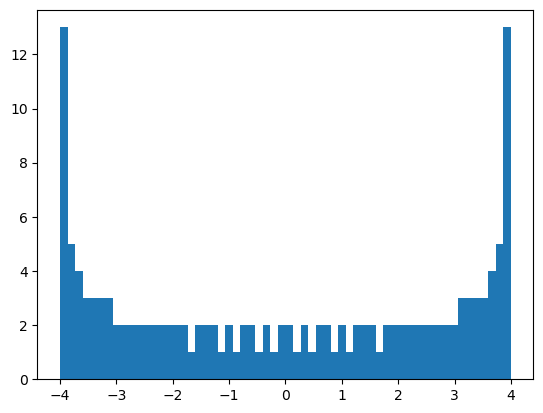

In [3]:
plt.hist(X[0],bins = 60);

In [15]:
THETA = np.array([[1/20,1]])
# Evaluate the function over the grid
Z_HF = M_HF(THETA)
# Evaluate the function over the grid
Z_LF = M_LF8(THETA)
noise_st_dev = 0.5
meas_data = generate_noisy_data(THETA, noise_st_dev, random_seed=16)

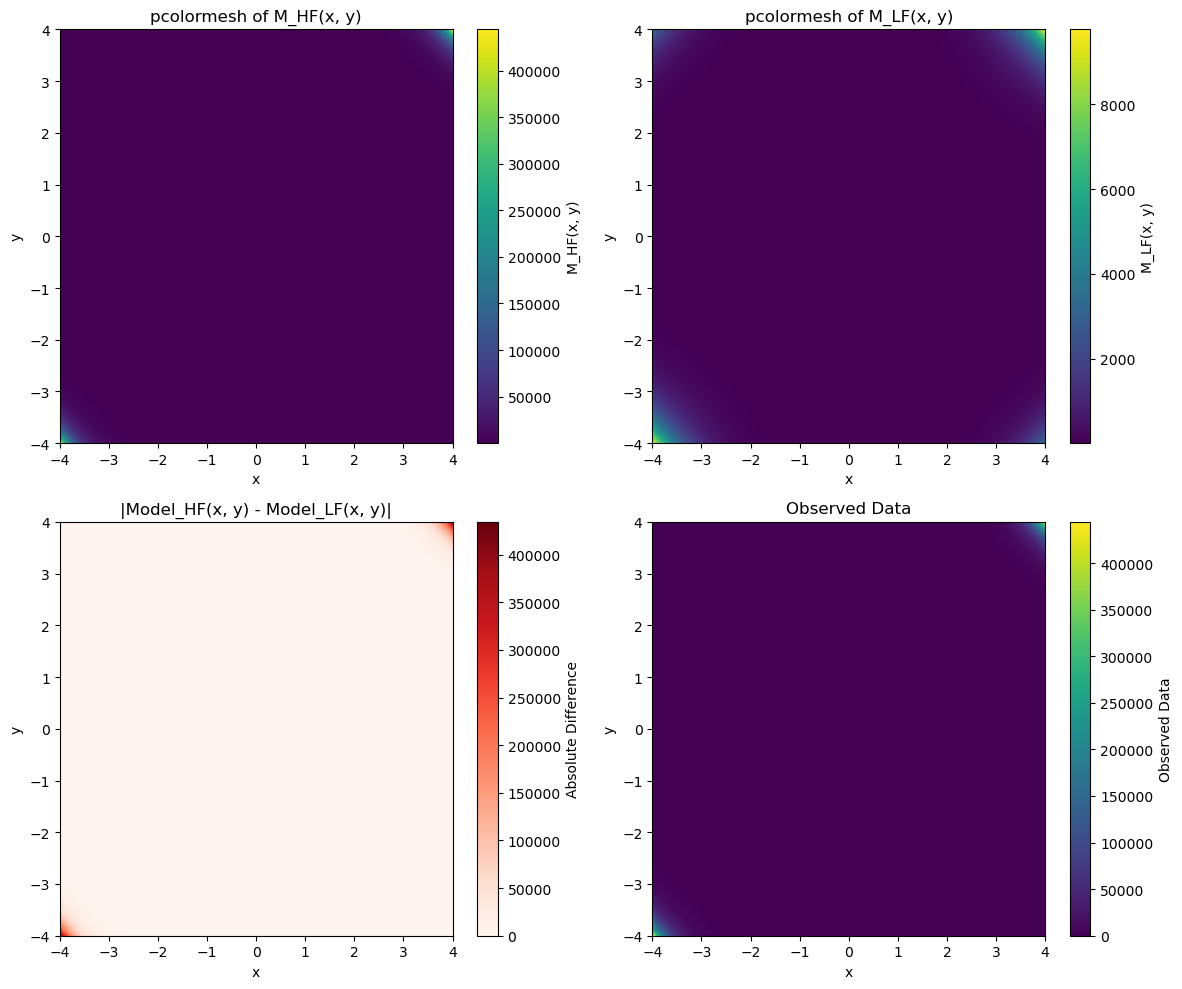

In [3]:
# Reshape the data once to keep the plotting lines clean
Z_HF_2D = Z_HF[0].reshape(resolution, resolution)
Z_LF_2D = Z_LF[0].reshape(resolution, resolution)
Z_diff = np.abs(Z_HF_2D - Z_LF_2D)
meas_data_2D = meas_data.reshape(resolution, resolution)

# Create a 2x2 subplot. figsize=(12, 10) gives it a nice boxy aspect ratio for 4 plots.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Subplot 1 (Top Left): High Fidelity ---
mesh1 = axes[0, 0].pcolormesh(X, Y, Z_HF_2D, shading='auto', cmap='viridis') 
fig.colorbar(mesh1, ax=axes[0, 0], label='M_HF(x, y)')
axes[0, 0].set_title('pcolormesh of M_HF(x, y)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')

# --- Subplot 2 (Top Right): Low Fidelity ---
mesh2 = axes[0, 1].pcolormesh(X, Y, Z_LF_2D, shading='auto', cmap='viridis')
fig.colorbar(mesh2, ax=axes[0, 1], label='M_LF(x, y)')
axes[0, 1].set_title('pcolormesh of M_LF(x, y)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')

# --- Subplot 3 (Bottom Left): Absolute Difference ---
mesh3 = axes[1, 0].pcolormesh(X, Y, Z_diff, shading='auto', cmap='Reds')
fig.colorbar(mesh3, ax=axes[1, 0], label='Absolute Difference')
axes[1, 0].set_title('|Model_HF(x, y) - Model_LF(x, y)|')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')

# --- Subplot 4 (Bottom Right): Observed Data ---
mesh4 = axes[1, 1].pcolormesh(X, Y, meas_data_2D, shading='auto', cmap='viridis')
fig.colorbar(mesh4, ax=axes[1, 1], label='Observed Data')
axes[1, 1].set_title('Observed Data')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')

# Adjust layout so the colorbars and titles don't overlap
plt.tight_layout()

# Display the plot
plt.show()